In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Pour ignorer les messages d'avertissement inutiles
import warnings
warnings.filterwarnings('ignore')

print("Bibliothèques chargées avec succès !")

Bibliothèques chargées avec succès !


In [2]:
# 1. Chargement du fichier
df = pd.read_excel(r'E:\projet stage PFE\PFE-Marjane-Optimization\marjane_data_villes.xlsx')

# 2. Nettoyage des textes et suppression des valeurs manquantes
df['Description'] = df['Description'].str.strip()
df.dropna(axis=0, subset=['Invoice', 'Description'], inplace=True)
df['Invoice'] = df['Invoice'].astype('str')

# 3. Suppression des annulations (Plus rapide : on garde uniquement les quantités positives)
df = df[df['Quantity'] > 0]

print("Données chargées et nettoyées !")
print(f"Nombre total de lignes : {len(df)}")

Données chargées et nettoyées !
Nombre total de lignes : 1024193


In [9]:
# Voir la distribution du support pour choisir le bon seuil
support_par_produit = basket_sets.sum() / len(basket_sets)
print(f"Support maximum  : {support_par_produit.max():.4f}")
print(f"Support minimum  : {support_par_produit.min():.4f}")
print(f"Support médian   : {support_par_produit.median():.4f}")
print(f"Support moyen    : {support_par_produit.mean():.4f}")

Support maximum  : 0.0667
Support minimum  : 0.0143
Support médian   : 0.0182
Support moyen    : 0.0205


In [17]:
# Stratégie : prendre TOUTES les villes (pas seulement Casablanca)
# et TOP 50 produits seulement

top_produits = df['Description'].value_counts().head(50).index
df_top = df[df['Description'].isin(top_produits)]

basket_sets2 = (df_top.groupby(['Invoice', 'Description'])['Quantity']
                .sum()
                .unstack(fill_value=0)
                .astype(bool))

# Garder seulement paniers avec 2+ produits
basket_sets2 = basket_sets2[basket_sets2.sum(axis=1) >= 2]

print(f"Shape nouvelle matrice : {basket_sets2.shape}")
print(f"Paniers multi-produits : {len(basket_sets2)}")

# FP-Growth sur données enrichies
frequent_itemsets2 = fpgrowth(basket_sets2, min_support=0.01, use_colnames=True)
print(f"Itemsets trouvés : {len(frequent_itemsets2)}")
print(frequent_itemsets2['itemsets'].apply(len).value_counts().sort_index())

Shape nouvelle matrice : (19555, 50)
Paniers multi-produits : 19555
Itemsets trouvés : 876
itemsets
1     50
2    691
3    126
4      9
Name: count, dtype: int64


In [18]:
rules = association_rules(frequent_itemsets2, metric="lift", min_threshold=1.0)

rules_filtrees = rules[
    (rules['lift'] > 1.5) &
    (rules['confidence'] > 0.3)
].sort_values('lift', ascending=False)

print(f"Règles totales    : {len(rules)}")
print(f"Règles filtrées   : {len(rules_filtrees)}")
rules_filtrees[['antecedents','consequents','support','confidence','lift']].head(10)

Règles totales    : 2200
Règles filtrées   : 455


,antecedents,consequents,support,confidence,lift
513,"(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN)","(LUNCH BAG WOODLAND, LUNCH BAG BLACK SKULL.)",0.014625,0.357947,8.578017
516,"(LUNCH BAG WOODLAND, LUNCH BAG BLACK SKULL.)","(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN)",0.014625,0.350490,8.578017
2149,"(LUNCH BAG SPACEBOY DESIGN, LUNCH BAG RED RETR...","(LUNCH BAG WOODLAND, LUNCH BAG BLACK SKULL.)",0.011455,0.356688,8.547833
2176,"(LUNCH BAG WOODLAND, LUNCH BAG RED RETROSPOT)","(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN)",0.010841,0.347541,8.505837
2145,"(LUNCH BAG WOODLAND, LUNCH BAG RED RETROSPOT)","(LUNCH BAG SPACEBOY DESIGN, LUNCH BAG BLACK S...",0.011455,0.367213,8.216078
2177,"(LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY D...","(LUNCH BAG CARS BLUE, LUNCH BAG WOODLAND)",0.010841,0.337580,8.159913
2160,"(LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT)","(LUNCH BAG WOODLAND, LUNCH BAG BLACK SKULL.)",0.010943,0.339683,8.140309
2174,"(LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT)","(LUNCH BAG WOODLAND, LUNCH BAG SPACEBOY DESIGN)",0.010841,0.336508,8.084045
706,"(SCOTTIE DOG HOT WATER BOTTLE, HOT WATER BOTTL...",(CHOCOLATE HOT WATER BOTTLE),0.015392,0.639066,7.980161
512,"(LUNCH BAG CARS BLUE, LUNCH BAG WOODLAND)","(LUNCH BAG BLACK SKULL., LUNCH BAG SPACEBOY D...",0.014625,0.353523,7.909771


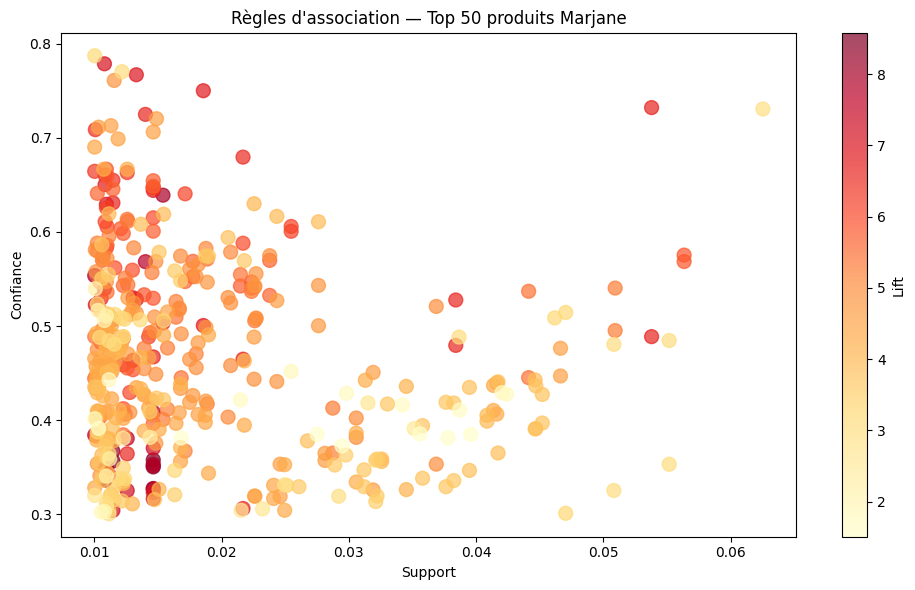

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules_filtrees['support'],
    rules_filtrees['confidence'],
    c=rules_filtrees['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    s=100
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confiance')
plt.title("Règles d'association — Top 50 produits Marjane")
plt.tight_layout()
plt.show()

In [20]:
# Top 5 recommandations claires pour Marjane
print("=" * 60)
print("TOP 5 RECOMMANDATIONS CROSS-SELLING POUR MARJANE")
print("=" * 60)

for i, row in rules_filtrees.head(5).iterrows():
    ant = list(row['antecedents'])
    con = list(row['consequents'])
    print(f"\n📦 Règle {i}")
    print(f"   Si client achète  : {ant}")
    print(f"   → Proposer aussi  : {con}")
    print(f"   Confiance : {row['confidence']:.1%} | Lift : {row['lift']:.2f}")

TOP 5 RECOMMANDATIONS CROSS-SELLING POUR MARJANE

📦 Règle 513
   Si client achète  : ['LUNCH BAG CARS BLUE', 'LUNCH BAG SPACEBOY DESIGN']
   → Proposer aussi  : ['LUNCH BAG WOODLAND', 'LUNCH BAG  BLACK SKULL.']
   Confiance : 35.8% | Lift : 8.58

📦 Règle 516
   Si client achète  : ['LUNCH BAG WOODLAND', 'LUNCH BAG  BLACK SKULL.']
   → Proposer aussi  : ['LUNCH BAG CARS BLUE', 'LUNCH BAG SPACEBOY DESIGN']
   Confiance : 35.0% | Lift : 8.58

📦 Règle 2149
   Si client achète  : ['LUNCH BAG SPACEBOY DESIGN', 'LUNCH BAG RED RETROSPOT']
   → Proposer aussi  : ['LUNCH BAG WOODLAND', 'LUNCH BAG  BLACK SKULL.']
   Confiance : 35.7% | Lift : 8.55

📦 Règle 2176
   Si client achète  : ['LUNCH BAG WOODLAND', 'LUNCH BAG RED RETROSPOT']
   → Proposer aussi  : ['LUNCH BAG CARS BLUE', 'LUNCH BAG SPACEBOY DESIGN']
   Confiance : 34.8% | Lift : 8.51

📦 Règle 2145
   Si client achète  : ['LUNCH BAG WOODLAND', 'LUNCH BAG RED RETROSPOT']
   → Proposer aussi  : ['LUNCH BAG SPACEBOY DESIGN', 'LUNCH BAG  BLACK